# Model evaluation

In [1]:
import os

import numpy as np
import pandas as pd

from matplotlib import pyplot as plt

from sklearn import metrics

import pickle

In [2]:
dataset_dir = "dataset"
models_dir = "models"

In [3]:
data_df = pd.read_csv(os.path.join(dataset_dir, "test_set.csv"))
X_test = data_df.drop(columns=["TARGET"])
y_test = data_df["TARGET"]

Each model's hard predictions and predicted probabilities are collected here so we can compare the models at the end.

In [4]:
results = {}

## Logistic regression

Load the model.

In [5]:
model_path = os.path.join(models_dir, "lr_pipe.pkl")
with open(model_path, "rb") as file:
    lr_pipe = pickle.load(file)

In [6]:
y_pred = lr_pipe.predict(X_test)
y_prob = lr_pipe.predict_proba(X_test)[:, 1]

In [7]:
print(metrics.classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.96      0.69      0.80     68917
         1.0       0.16      0.68      0.26      6083

    accuracy                           0.69     75000
   macro avg       0.56      0.68      0.53     75000
weighted avg       0.90      0.69      0.76     75000



In [8]:
print(f"ROC AUC Score: {metrics.roc_auc_score(y_test, y_prob)}")

ROC AUC Score: 0.7487653245465387


In [9]:
results["Logistic regression"] = {"y_pred": y_pred, "y_prob": y_prob}

## XGBoost

In [10]:
model_path = os.path.join(models_dir, "xgb_clf.pkl")
with open(model_path, "rb") as file:
    xgb_clf = pickle.load(file)

In [11]:
y_pred = xgb_clf.predict(X_test)
y_prob = xgb_clf.predict_proba(X_test)[:, 1]

In [12]:
print(metrics.classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.94      0.90      0.92     68917
         1.0       0.21      0.31      0.25      6083

    accuracy                           0.85     75000
   macro avg       0.57      0.60      0.58     75000
weighted avg       0.88      0.85      0.86     75000



In [13]:
print(f"ROC AUC Score: {metrics.roc_auc_score(y_test, y_prob)}")

ROC AUC Score: 0.6966040264512672


In [14]:
results["XGBoost"] = {"y_pred": y_pred, "y_prob": y_prob}

## Fully-connected neural network

In [15]:
import torch

The model class is defined in *model.py* and shared with the training notebook.

In [16]:
DROPOUT = 0.3

In [17]:
from model import NNBinaryClassifier

Load the scaler

In [18]:
scaler_path = os.path.join(models_dir, "scaler.pkl")
with open(scaler_path, "rb") as f:
    scaler = pickle.load(f)

X_test_t = scaler.transform(X_test)

In [19]:
X_test_t = torch.tensor(X_test_t, dtype=torch.float32)

Loading the model.

In [20]:
num_features = X_test_t.shape[1]

In [21]:
model_path = os.path.join(models_dir, "fcnn.pt")
fcnn = NNBinaryClassifier(in_features=num_features, dropout=DROPOUT)
fcnn.load_state_dict(torch.load(model_path, weights_only=True))

<All keys matched successfully>

In [22]:
fcnn.eval()
with torch.no_grad():
    y_logits = fcnn(X_test_t)
    y_prob = torch.sigmoid(y_logits).numpy().flatten()

y_pred = (y_prob > 0.5).astype(np.float32)

print(metrics.classification_report(y_test, y_pred))
print(f"ROC AUC Score: {metrics.roc_auc_score(y_test, y_prob)}")

              precision    recall  f1-score   support

         0.0       0.96      0.67      0.79     68917
         1.0       0.16      0.70      0.26      6083

    accuracy                           0.67     75000
   macro avg       0.56      0.68      0.52     75000
weighted avg       0.90      0.67      0.75     75000

ROC AUC Score: 0.7463389782892439


In [23]:
results["Neural network"] = {"y_pred": y_pred, "y_prob": y_prob}

## Model comparison

We use ROC curves for model comparison.

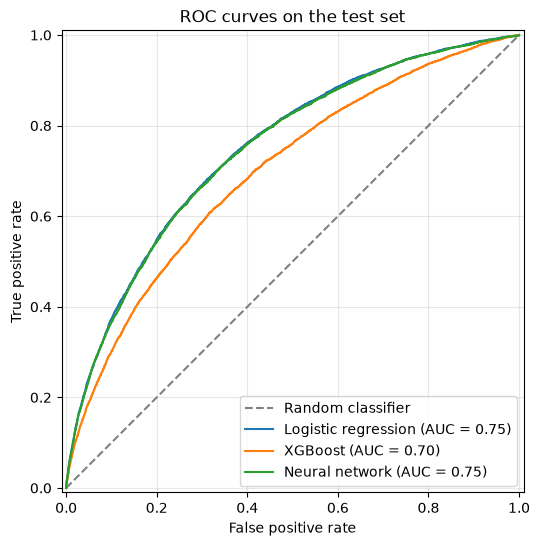

In [24]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random classifier")

for name, res in results.items():
    metrics.RocCurveDisplay.from_predictions(y_test, res["y_prob"], name=name, ax=ax)

ax.set_title("ROC curves on the test set")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.grid(alpha=0.3)
ax.legend(loc="lower right")
plt.show()

Summary of all metrics

In [25]:
summary_df = pd.DataFrame([
    {
        "Model": name,
        "ROC AUC": metrics.roc_auc_score(y_test, res["y_prob"]),
        "Average precision": metrics.average_precision_score(y_test, res["y_prob"]),
        "F1 (default)": metrics.f1_score(y_test, res["y_pred"]),
        "Precision (default)": metrics.precision_score(y_test, res["y_pred"]),
        "Recall (default)": metrics.recall_score(y_test, res["y_pred"]),
        "Accuracy": metrics.accuracy_score(y_test, res["y_pred"]),
    }
    for name, res in results.items()
]).set_index("Model").round(3)

summary_df

,ROC AUC,Average precision,F1 (default),Precision (default),Recall (default),Accuracy
Model,,,,,,
Logistic regression,0.749,0.229,0.261,0.162,0.682,0.688
XGBoost,0.697,0.183,0.248,0.208,0.308,0.849
Neural network,0.746,0.224,0.256,0.157,0.695,0.673


## Feature importance

The XGBoost and logistic regression models can interpret how much features are important (i.e., how much they contribute to the final decision). We plot the comparison.

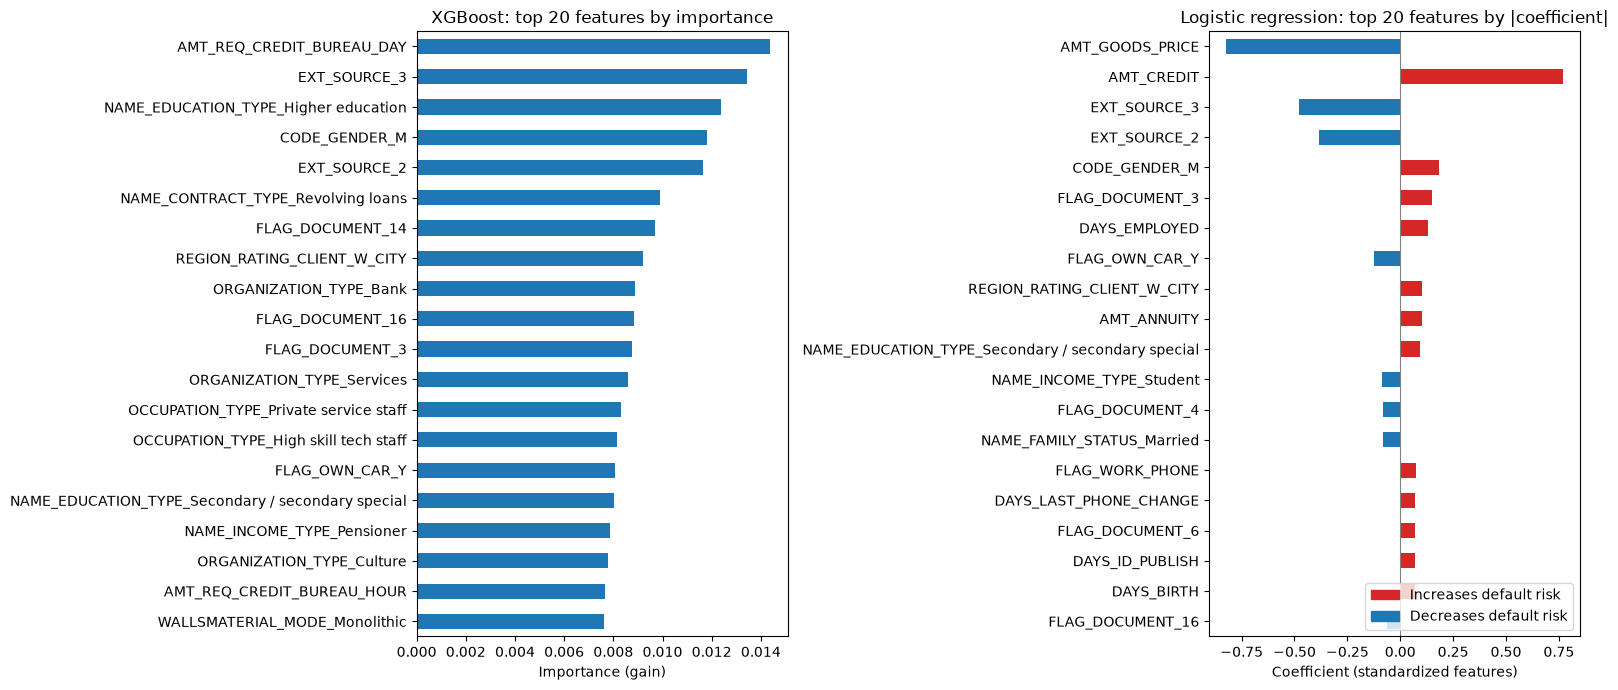

In [26]:
xgb_importances = pd.Series(xgb_clf.feature_importances_, index=X_test.columns).nlargest(20)

lr_coefs = pd.Series(lr_pipe.named_steps["lr"].coef_[0], index=X_test.columns)
lr_top_coefs = lr_coefs.reindex(lr_coefs.abs().nlargest(20).index)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

xgb_importances.iloc[::-1].plot.barh(ax=ax1)
ax1.set_title("XGBoost: top 20 features by importance")
ax1.set_xlabel("Importance (gain)")

coef_colors = ["tab:red" if c > 0 else "tab:blue" for c in lr_top_coefs.iloc[::-1]]
lr_top_coefs.iloc[::-1].plot.barh(ax=ax2, color=coef_colors)
ax2.axvline(0, color="gray", linewidth=0.8)
ax2.set_title("Logistic regression: top 20 features by |coefficient|")
ax2.set_xlabel("Coefficient (standardized features)")
ax2.legend(
    handles=[
        plt.Rectangle((0, 0), 1, 1, color="tab:red", label="Increases default risk"),
        plt.Rectangle((0, 0), 1, 1, color="tab:blue", label="Decreases default risk")
    ],
    loc="lower right"
)

plt.tight_layout()
plt.show()